In [36]:
# RUN THIS CELL
!pip install --upgrade --no-cache-dir gdown
!pip install tf_keras_vis

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [37]:
# import the packages that we need 
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tf_keras_vis.utils import normalize
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.saliency import Saliency
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential, Model
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, Flatten, Activation, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import SGD
import os
from tensorflow.keras import backend as K
from tensorflow.keras.utils import plot_model

In [38]:
# RUN THIS CELL - IF ON COLAB To Download the dataset 
!gdown --id 1vUqvrd0nNwVZ-cVuwpYqZ5VSstLAf4lM

/usr/local/lib/python3.10/dist-packages/gdown/cli.py:126: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (uriginal): https://drive.google.com/uc?id=1vUqvrd0nNwVZ-cVuwpYqZ5VSstLAf4lM
From (redirected): https://drive.google.com/uc?id=1vUqvrd0nNwVZ-cVuwpYqZ5VSstLAf4lM&confirm=t&uuid=c87ce55a-0a5b-4ede-a2d5-b30ecf4fc314
To: /content/archive.zip
100% 63.3M/63.3M [00:00<00:00, 147MB/s]


In [39]:
# RUN THIS CELL to extract the zip file
from zipfile import ZipFile 

# specifying the zip file name 
file_name = "/content/archive.zip"

# opening the zip file in READ mode 
with ZipFile(file_name, 'r') as zip: 

    # extracting all the files 
    print('Extracting all the files now...') 
    zip.extractall() 

Extracting all the files now...


In [40]:
# Create the main DataGenerator object with arguments of your choice
datagen = ImageDataGenerator(
    rescale=1./255, # Rescale the pixel values to [0,1] range
    validation_split=0.2, # Use 20% of the data for validation
    rotation_range=20, # Rotate the images randomly by 20 degrees
    width_shift_range=0.1, # Shift the images horizontally by 10% of the width
    height_shift_range=0.1, # Shift the images vertically by 10% of the height
    zoom_range=0.1, # Zoom the images randomly by 10%
    horizontal_flip=True # Flip the images horizontally
)



In [49]:
traingen = datagen.flow_from_directory(
    directory='train', # The directory where the training images are stored
    target_size=(48, 48), # The target size of the images
    class_mode='categorical', # The class mode of the labels
    batch_size=256, # The batch size of the data
    shuffle=True, # Shuffle the data randomly
    subset='training', # Use the training subset of the data
    classes=['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'] # Specify the classes you want
)


valgen = datagen.flow_from_directory(
    directory='train', # The directory where the validation images are stored
    target_size=(48, 48), # The target size of the images
    class_mode='categorical', # The class mode of the labels
    batch_size=256, # The batch size of the data
    shuffle=False, # Do not shuffle the data
    subset='validation', # Use the validation subset of the data
    classes=['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'] # Specify the classes you want
)

testgen = datagen.flow_from_directory(
    directory='test', # The directory where the validation images are stored
    target_size=(48, 48), # The target size of the images
    class_mode='categorical', # The class mode of the labels
    batch_size=256, # The batch size of the data
    shuffle=False, # Do not shuffle the data
    subset='validation', # Use the validation subset of the data
    classes=['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'] # Specify the classes you want
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 1432 images belonging to 7 classes.


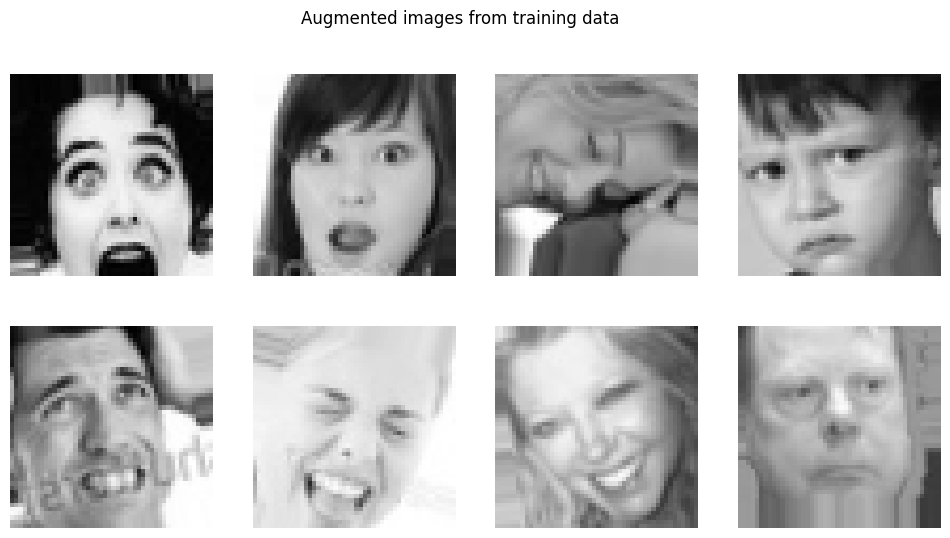

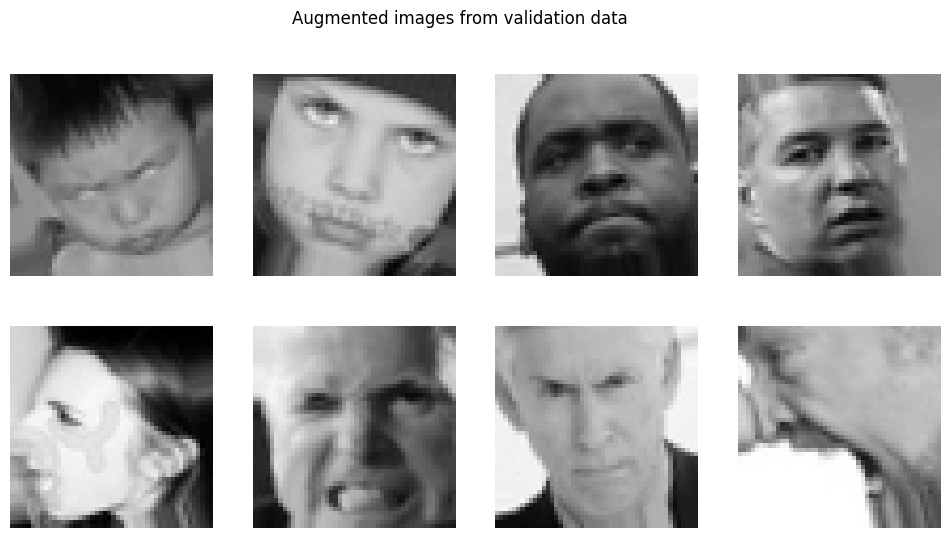

In [42]:
# Visualize a few augmented images from the train and validation data
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    x_batch, y_batch = traingen.next()
    plt.imshow(x_batch[0])
    plt.axis('off')
plt.suptitle('Augmented images from training data')
plt.show()

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    x_batch, y_batch = valgen.next()
    plt.imshow(x_batch[0])
    plt.axis('off')
plt.suptitle('Augmented images from validation data')
plt.show()


In [51]:
from tensorflow import keras
# 定义 VGG16 模型
def VGG16(input_shape=(48, 48, 3), num_classes=7):
  model = keras.Sequential([
        # 第一段卷积层
        keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2, 2)),
    
        # 第二段卷积层
        keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2, 2)),
    
        # 第三段卷积层
        keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2, 2)),
    
        # 第四段卷积层
        keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2, 2)),
    
    
        # 全连接层
        keras.layers.Flatten(),
        keras.layers.Dense(512, activation='relu'),
        keras.layers.Dense(512, activation='relu'),
        keras.layers.Dense(num_classes, activation='softmax')
    ])
  return model

model = VGG16()
# Compiling the model
model.compile(optimizer=SGD(lr=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()
 
    


Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_69 (Conv2D)          (None, 48, 48, 64)        1792      
                                                                 
 conv2d_70 (Conv2D)          (None, 48, 48, 64)        36928     
                                                                 
 max_pooling2d_27 (MaxPoolin  (None, 24, 24, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_71 (Conv2D)          (None, 24, 24, 128)       73856     
                                                                 
 conv2d_72 (Conv2D)          (None, 24, 24, 128)       147584    
                                                                 
 max_pooling2d_28 (MaxPoolin  (None, 12, 12, 128)      0         
 g2D)                                                 

In [ ]:

# Train the model for 10 epochs
history = model.fit(
    traingen, # The training data generator
    epochs=10, # The number of epochs to train
    validation_data=valgen, # The validation data generator
    steps_per_epoch=len(traingen), # The number of steps per epoch
    validation_steps=len(valgen) # The number of validation steps
)

Epoch 1/10
90/90 [==============================] - 2267s 25s/step - loss: 1.9141 - accuracy: 0.2495 - val_loss: 1.8857 - val_accuracy: 0.2513
Epoch 2/10
46/90 [==============>...............] - ETA: 17:19 - loss: 1.8740 - accuracy: 0.2478